# Pipeline
1.Tokenizer -> 2.File to Tokenizer -> 3.Tokenzier to New File -> 4. Data Converted to Numerical -> 5. Train Model -> 6. Evaluate -> 7. Manual Testing

In [224]:
#TOKENIZER
import pandas as pd
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

In [225]:
df=pd.read_csv('email.csv')

In [226]:
datafile=open('data.txt','w',encoding='utf_8')
for i in df['Message'].astype(str):
    datafile.write(i+'\n')

In [227]:
tokenizer=Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer=Whitespace()
trainer=BpeTrainer(vocab_size=10000,special_tokens=['[UNK]','[PAD]'])
tokenizer.train(['data.txt'],trainer)

Max_length=100
tokenizer.enable_padding(pad_id=tokenizer.token_to_id('[PAD]'),length=Max_length)
tokenizer.enable_truncation(max_length=Max_length)

In [228]:
#data converted to Numerics
x_list=[]
for i in df['Message'].astype(str):
    encoded=tokenizer.encode(i)
    x_list.append(encoded.ids)

In [229]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.preprocessing import StandardScaler,LabelEncoder
from xgboost import XGBClassifier

In [230]:
coder=LabelEncoder()
df['spam/ham']=coder.fit_transform(df['Category'])
x=np.array(x_list)
y=df['spam/ham']

In [231]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [232]:
scaler=StandardScaler()
x_train_n=scaler.fit_transform(x_train)
x_test_n=scaler.fit_transform(x_test)

In [233]:
model=XGBClassifier()
model.fit(x_train_n,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [234]:
model2=GradientBoostingClassifier(n_estimators=100,max_depth=2,learning_rate=0.2,random_state=32)
model2.fit(x_train_n,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [235]:
model3=LogisticRegression()
model3.fit(x_train_n,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Evaluation

In [236]:
predict1=model.predict(x_test_n)
accuracy=accuracy_score(predict1,y_test)
predict2=model.predict(x_train_n)
acc=accuracy_score(predict2,y_train)
confusionm=confusion_matrix(predict1,y_test)
confusion=confusion_matrix(predict2,y_train)
print(f"Training Accurcy: {acc*100:.2f}%\nTesting Accuracy: {accuracy*100:.2f}%")
print(f"confusion_matrix of Training Accuracy: \n{confusion}\nConfusion Matrix of Testing Accuracy: \n{confusionm}")

Training Accurcy: 100.00%
Testing Accuracy: 90.22%
confusion_matrix of Training Accuracy: 
[[3867    0    0]
 [   0  590    0]
 [   0    0    1]]
Confusion Matrix of Testing Accuracy: 
[[930  81]
 [ 28  76]]


In [237]:
predct1=model2.predict(x_test_n)
acuracy=accuracy_score(predct1,y_test)
predct2=model2.predict(x_train_n)
ac=accuracy_score(predct2,y_train)
confusinm=confusion_matrix(predct1,y_test)
confusin=confusion_matrix(predct2,y_train)
print(f"Training Accurcy: {ac*100:.2f}%\nTesting Accuracy: {acuracy*100:.2f}%")
print(f"confusion_matrix of Training Accuracy: \n{confusin}\nConfusion Matrix of Testing Accuracy: \n{confusinm}")

Training Accurcy: 96.14%
Testing Accuracy: 88.43%
confusion_matrix of Training Accuracy: 
[[3839  144    0]
 [  28  446    0]
 [   0    0    1]]
Confusion Matrix of Testing Accuracy: 
[[922  93]
 [ 36  64]]


In [238]:
predct=model3.predict(x_test_n)
acccuracy=accuracy_score(predct,y_test)
predct3=model3.predict(x_train_n)
accs=accuracy_score(predct3,y_train)
confusinmat=confusion_matrix(predct,y_test)
moconfusin=confusion_matrix(predct3,y_train)
print(f"Training Accurcy: {accs*100:.2f}%\nTesting Accuracy: {acccuracy*100:.2f}%")
print(f"confusion_matrix of Training Accuracy: \n{moconfusin}\nConfusion Matrix of Testing Accuracy: \n{confusinmat}")

Training Accurcy: 89.01%
Testing Accuracy: 86.91%
confusion_matrix of Training Accuracy: 
[[3737  359    1]
 [ 130  231    0]
 [   0    0    0]]
Confusion Matrix of Testing Accuracy: 
[[917 105]
 [ 41  52]]


# Manualy Testing Module

In [239]:
text1=['I have finished the first draft of the Q3 marketing presentation. The slide deck is now saved in our shared project folder.Could you please review the budget slides and the upcoming campaign timeline before our team meeting? I want to make sure the data matches your latest revenue projections.Please add your comments directly to the file by Thursday afternoon so I can make final adjustments.']
text=["Congratulations! You have been selected to receive an exclusive reward of $1,000,000 as part of our global anniversary celebration. This limited-time offer is guaranteed to change your life, but you must act now. To claim your prize, simply click the link below and provide your personal information."]
#data converted to Numerics
xlist=[]
for i in text:
    encoded=tokenizer.encode(i)
    xlist.append(encoded.ids)

In [240]:
p=model.predict(xlist)
p2=model2.predict(xlist)
p3=model3.predict(xlist)

In [241]:
if p==[0]:
    print("Not Spam")
else: print("Spam")

Not Spam


In [242]:
if p2==[0]:
    print("Not Spam")
else: print("Spam")

Spam


In [243]:
if p3==[0]:
    print("Not Spam")
else: print("Spam")

Not Spam


# Visualization of each model Accuracy

In [ ]:
# Visualization of models accuracy
n=['XGBClassifier','GradientBoostingClassifier','LogisticRegression']
training_accuracy=[acc,ac,accs]
testing_accuracy=[accuracy,acuracy,acccuracy]

In [245]:
import matplotlib.pyplot as plt


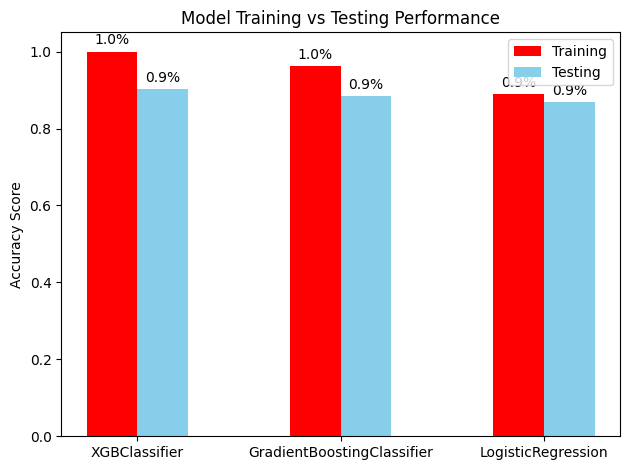

In [264]:
y=np.arange(len(n))
width=0.25
bar1=plt.bar(y-(width/2),training_accuracy,width,color='red',label='Training')
bar2=plt.bar(y+(width/2),testing_accuracy,width,color='skyblue',label='Testing')
plt.xticks(ticks=[0,1,2],labels=n)
plt.bar_label(bar1, padding=3, fmt='%.1f%%')
plt.bar_label(bar2, padding=3, fmt='%.1f%%')
plt.ylabel('Accuracy Score')
plt.title('Model Training vs Testing Performance')
plt.legend()
plt.tight_layout()
plt.show()